## Univariate Time Series

Univariate time series adalah *serangkaian data yang direkam dalam interval waktu yang berurutan, di mana setiap titik data memiliki satu variabel yang diamati atau diukur*. Ini berarti bahwa dalam analisis univariate time series, kita hanya memperhatikan satu variabel dalam rentang waktu tertentu.

In [7]:
import numpy as np
import pandas as pd
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
import tensorflow as tf

In [15]:
import os
import urllib.request

# Download dataset dari Google Drive jika belum ada secara lokal
csv_path = 'DailyDelhiClimateTrain.csv'
if not os.path.exists(csv_path):
    url = 'https://drive.google.com/uc?id=15RfMD9lNkpS3cVN7j3_dsJKZ8_5RJG5z'
    urllib.request.urlretrieve(url, csv_path)

df = pd.read_csv(csv_path)
df.head()



,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [16]:
df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [17]:
dates = df['date'].values
temp = df['meantemp'].values

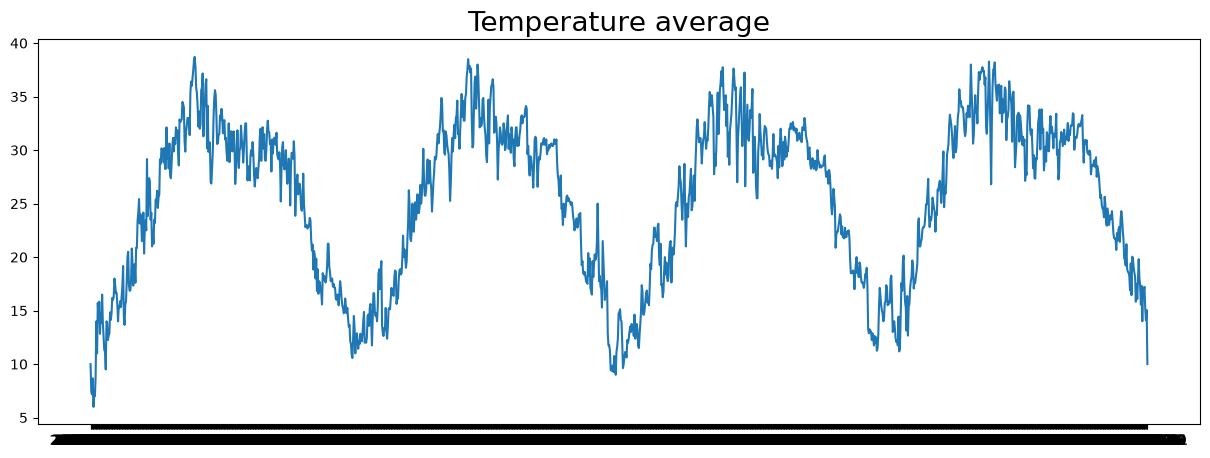

In [18]:
plt.figure(figsize=(15, 5))
plt.plot(dates, temp)
plt.title('Temperature average', fontsize=20);

In [20]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:1], w[:-1]))
    return ds.batch(batch_size).prefetch(1)

train_set = windowed_dataset(temp, window_size=60, batch_size=100, shuffle_buffer=1000)
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(60, return_sequences=True),
    tf.keras.layers.LSTM(60),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1),
])

In [21]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1.0000e-04, momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])
history = model.fit(train_set,epochs=100)

Epoch 1/100


/Users/yutaaa/Developments/daily-climate-series/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 25.4159 - mae: 25.9159
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.3906 - mae: 25.8906 
Epoch 3/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 25.1384 - mae: 25.6384

/Users/yutaaa/Developments/daily-climate-series/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.3652 - mae: 25.8652 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.3441 - mae: 25.8441 
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.3222 - mae: 25.8222 
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.3005 - mae: 25.8005 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.2793 - mae: 25.7793 
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.2583 - mae: 25.7583 
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25.2375 - mae: 25.7375 
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.2169 - mae: 25.7169 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.1964 - mae: 25.6964 
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.1758 - mae: 25.6757 
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.1551 - mae: 25.6551 
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.1343 - mae: 25.6343 
Epoch 15/10

In [22]:
forecast = history.model.predict(train_set)
forecast

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/Users/yutaaa/Developments/daily-climate-series/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


array([[27.864906],
       [28.296862],
       [28.934813],
       ...,
       [28.685955],
       [28.595785],
       [26.58052 ]], shape=(1402, 1), dtype=float32)